In [78]:
import sqlite3
import pandas as pd
from IPython.display import display, HTML
import plotly.express as px
import plotly.io as pio
con = sqlite3.connect("chess.db")
cur = con.cursor()

In [79]:
def søk():
    print(name)
    print("Average length of games:",  sum(sok2['ply_count'])/len(sok2['ply_count']))
    # Puts the scrollbar next to the DataFrame
    df_temp = sok2.groupby('colour')['result'].value_counts(normalize = True).to_frame()
    print(df_temp)
    display(
        HTML(
            "<div style='height: 400px; overflow: auto; width: fit-content'>" +
            sok2.to_html() +
            "</div>"
        )
    )

In [80]:
def openings():
    df_temp = sok2['eco'].value_counts().to_frame()
    df_temp.reset_index(inplace = True)
    last_played_dates = sok2.groupby('eco')['date_played'].max().reset_index()
    last_played_dates.rename(columns={'date_played': 'last_played'}, inplace=True)
    df_temp = df_temp.merge(last_played_dates, on='eco', how='left')
    display(
        HTML(
            "<div style='height: 400px; overflow: auto; width: fit-content'>" +
            df_temp.to_html() +
            "</div>"
        )
    )

In [81]:
def player():
    df_temp2 = sok2['opponent'].value_counts().to_frame()
    df_temp2.reset_index(inplace = True)
    last_played_dates = sok2.groupby('opponent')['date_played'].max().reset_index()
    last_played_dates.rename(columns={'date_played': 'last_played'}, inplace=True)
    df_temp2 = df_temp2.merge(last_played_dates, on='opponent', how='left')
    display(
        HTML(
            "<div style='height: 400px; overflow: auto; width: fit-content'>" +
            df_temp2.to_html() +
            "</div>"
        )
    )

In [82]:
def endgame():
    df_temp3 = sok2['endgame'].value_counts().to_frame()
    df_temp3.reset_index(inplace = True)
    last_played_dates = sok2.groupby('endgame')['date_played'].max().reset_index()
    last_played_dates.rename(columns={'date_played': 'last_played'}, inplace=True)
    df_temp3 = df_temp3.merge(last_played_dates, on='endgame', how='left')
    display(
        HTML(
            "<div style='height: 400px; overflow: auto; width: fit-content'>" +
            df_temp3.to_html() +
            "</div>"
        )
    )

In [83]:
# Get the player's name from the user
player_name = input("Enter the player's name: ")

# Query to search for players by name
query = f"""SELECT fide_id, name FROM player WHERE name LIKE '%{player_name}%'"""
players = pd.read_sql(query, con)

if players.empty:
    print("No players found with the given name.")
elif len(players) == 1:
    id = players.iloc[0]["fide_id"]
    query = f"""SELECT t.event, g.date_played, CASE WHEN g.white = '{id}' THEN 'White' WHEN g.black = '{id}' THEN 'Black' END AS colour, CASE WHEN g.white = '{id}' THEN g.black WHEN g.black = '{id}' THEN g.white END AS opponent, g.result, CASE WHEN g.white = '{id}' THEN white_elo WHEN g.black = '{id}' THEN black_elo END AS elo, g.eco, g.ply_count, g.termination, g.endgame, g.endgame_count FROM games g JOIN tournament t ON g.event = t.event_id WHERE g.white = '{id}' OR g.black = '{id}' ORDER BY date_played ASC"""
    sok2 = pd.read_sql(query, con)
    query = f"""SELECT * FROM player WHERE fide_id = '{id}'"""
    name = pd.read_sql(query, con)
    søk()
    openings()
    player()
    endgame()
else:
    # Display the list of players found
    print("Players found:")

    # Handle multiple matches
    if len(players) > 1:
        print("Multiple players found. Please choose the correct FIDE ID.")
        display(
            HTML(
                "<div style='height: 200px; overflow: auto; width: fit-content'>" +
                players.to_html() +
                "</div>"
            )
        )
    id = input("Enter your Fide ID:")
    query = f"""SELECT t.event, g.date_played, CASE WHEN g.white = '{id}' THEN 'White' WHEN g.black = '{id}' THEN 'Black' END AS colour, CASE WHEN g.white = '{id}' THEN g.black WHEN g.black = '{id}' THEN g.white END AS opponent, g.result, CASE WHEN g.white = '{id}' THEN white_elo WHEN g.black = '{id}' THEN black_elo END AS elo, g.eco, g.ply_count, g.termination, g.endgame, g.endgame_count FROM games g JOIN tournament t ON g.event = t.event_id WHERE g.white = '{id}' OR g.black = '{id}' ORDER BY date_played ASC"""
    sok2 = pd.read_sql(query, con)
    query = f"""SELECT * FROM player WHERE fide_id = '{id}'"""
    name = pd.read_sql(query, con)
    søk()
    openings()
    player()
    endgame()
con.close

Enter the player's name:  rozman


   fide_id          name country sex title
0  2039877  Rozman, Levy     USA   M    IM
Average length of games: nan
                proportion
colour result             
Black  0-1        0.481100
       1-0        0.399771
       1/2-1/2    0.119129
White  1-0        0.562796
       0-1        0.337678
       1/2-1/2    0.099526


,event,date_played,colour,opponent,result,elo,eco,ply_count,termination,endgame,endgame_count
0,Washington International 2012,2012.07.28,White,1200496,0-1,2200.0,C77,75.0,resignation,Rook + Pawn vs Rook + Pawn,2.0
1,Washington International 2012,2012.07.28,Black,5005370,1-0,2200.0,A07,40.0,resignation,Ended Before Endgame,1.0
2,Washington International 2012,2012.07.29,Black,2032562,1/2-1/2,2200.0,D45,44.0,draw by agreement,Ended Before Endgame,1.0
3,Washington International 2012,2012.07.30,White,2001861,0-1,2200.0,B00,24.0,resignation,Ended Before Endgame,1.0
4,Washington International 2012,2012.07.30,Black,2006898,0-1,2200.0,B13,50.0,resignation,Ended Before Endgame,1.0
5,Washington International 2012,2012.07.31,Black,2005603,0-1,2200.0,B12,34.0,resignation,Ended Before Endgame,1.0
6,Washington International 2012,2012.08.01,White,2034239,0-1,2200.0,B18,32.0,resignation,Ended Before Endgame,1.0
7,US Amateur Team East 2013,2013.02.17,White,2000172,0-1,2205.0,B47,44.0,resignation,Ended Before Endgame,1.0
8,US Chess Masters 2014,2014.08.28,Black,14118084,1-0,2287.0,A81,34.0,resignation,Ended Before Endgame,1.0
9,US Chess Masters 2014,2014.08.30,Black,2020165,1-0,2287.0,A81,38.0,resignation,Ended Before Endgame,1.0


,eco,count,last_played
0,B01,159,2025.03.04
1,A45,109,2025.03.25
2,B20,96,2024.11.05
3,A40,87,2025.04.08
4,B12,71,2025.04.01
5,C00,69,2025.04.01
6,A04,60,2025.04.08
7,B23,59,2025.01.07
8,B06,49,2025.04.08
9,B10,49,2024.09.24


,opponent,count,last_played
0,2009064,49,2023.10.16
1,1700030,44,2024.11.02
2,505161,27,2023.10.12
3,2032562,21,2022.05.26
4,2109450,21,2023.01.03
5,5007844,20,2020.04.19
6,24171760,20,2023.10.19
7,24125890,9,2025.03.25
8,34164453,9,2024.11.19
9,4158814,8,2024.11.19


,endgame,count,last_played
0,Ended Before Endgame,1453,2025.04.08
1,Rook vs Rook,56,2025.04.01
2,Rook + Pawn vs Rook + Pawn,44,2025.03.25
3,King + Pawn vs King,31,2025.03.25
4,Pawn endings,26,2025.04.08
5,Queen + Pawn vs Queen + Pawn,14,2024.10.22
6,black bishop + pawn vs knight + pawns,12,2025.01.14
7,Queen vs Queen,11,2024.10.22
8,Same-Colored Bishop Endings,8,2025.01.20
9,black bishop + pawn vs pawn,5,2024.09.24


<function Connection.close()>

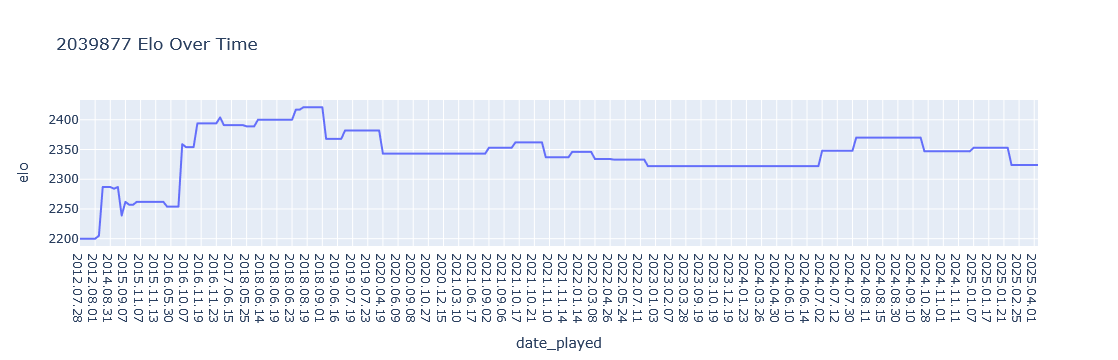

In [84]:
fig = px.line(sok2, x='date_played', y='elo', title=f'{id} Elo Over Time')
fig.show()

In [85]:
df_temp = sok2['eco'].value_counts().to_frame()
df_temp.reset_index(inplace = True)
last_played_dates = sok2.groupby('eco')['date_played'].max().reset_index()
last_played_dates.rename(columns={'date_played': 'last_played'}, inplace=True)
df_temp = df_temp.merge(last_played_dates, on='eco', how='left')
display(
    HTML(
        "<div style='height: 400px; overflow: auto; width: fit-content'>" +
        df_temp.to_html() +
        "</div>"
    )
)
df_temp2 = sok2['opponent'].value_counts().to_frame()
df_temp2.reset_index(inplace = True)
last_played_dates = sok2.groupby('opponent')['date_played'].max().reset_index()
last_played_dates.rename(columns={'date_played': 'last_played'}, inplace=True)
df_temp2 = df_temp2.merge(last_played_dates, on='opponent', how='left')
display(
    HTML(
        "<div style='height: 400px; overflow: auto; width: fit-content'>" +
        df_temp2.to_html() +
        "</div>"
    )
)
df_temp3 = sok2['endgame'].value_counts().to_frame()
df_temp3.reset_index(inplace = True)
last_played_dates = sok2.groupby('endgame')['date_played'].max().reset_index()
last_played_dates.rename(columns={'date_played': 'last_played'}, inplace=True)
df_temp3 = df_temp3.merge(last_played_dates, on='endgame', how='left')
display(
    HTML(
        "<div style='height: 400px; overflow: auto; width: fit-content'>" +
        df_temp3.to_html() +
        "</div>"
    )
)

,eco,count,last_played
0,B01,159,2025.03.04
1,A45,109,2025.03.25
2,B20,96,2024.11.05
3,A40,87,2025.04.08
4,B12,71,2025.04.01
5,C00,69,2025.04.01
6,A04,60,2025.04.08
7,B23,59,2025.01.07
8,B06,49,2025.04.08
9,B10,49,2024.09.24


,opponent,count,last_played
0,2009064,49,2023.10.16
1,1700030,44,2024.11.02
2,505161,27,2023.10.12
3,2032562,21,2022.05.26
4,2109450,21,2023.01.03
5,5007844,20,2020.04.19
6,24171760,20,2023.10.19
7,24125890,9,2025.03.25
8,34164453,9,2024.11.19
9,4158814,8,2024.11.19


,endgame,count,last_played
0,Ended Before Endgame,1453,2025.04.08
1,Rook vs Rook,56,2025.04.01
2,Rook + Pawn vs Rook + Pawn,44,2025.03.25
3,King + Pawn vs King,31,2025.03.25
4,Pawn endings,26,2025.04.08
5,Queen + Pawn vs Queen + Pawn,14,2024.10.22
6,black bishop + pawn vs knight + pawns,12,2025.01.14
7,Queen vs Queen,11,2024.10.22
8,Same-Colored Bishop Endings,8,2025.01.20
9,black bishop + pawn vs pawn,5,2024.09.24


In [86]:
df_temp

,eco,count,last_played
0,B01,159,2025.03.04
1,A45,109,2025.03.25
2,B20,96,2024.11.05
3,A40,87,2025.04.08
4,B12,71,2025.04.01
...,...,...,...
141,E11,1,2022.04.26
142,E40,1,2022.05.09
143,C20,1,2022.05.09
144,D09,1,2022.10.04


In [87]:
def find_winner(row):
    if row['colour'] == 'White':
        if row['result'] == '1-0':
            return 'Win'
        elif row['result'] == '0-1':
            return 'Loss'
        elif row['result'] == '1/2-1/2':
            return 'Draw'
    elif row['colour'] == 'Black':
        if row['result'] == '1-0':
            return 'Loss'
        elif row['result'] == '0-1':
            return 'Win'
        elif row['result'] == '1/2-1/2':
            return 'Draw'

In [88]:
games = sok2[['event','date_played' ,'colour', 'result', 'eco', 'ply_count', 'termination', 'endgame']]

In [89]:
games['result'] = games.apply(find_winner, axis=1)

C:\Users\Ole Martin\AppData\Local\Temp\ipykernel_16496\3341497478.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [90]:
games

,event,date_played,colour,result,eco,ply_count,termination,endgame
0,Washington International 2012,2012.07.28,White,Loss,C77,75.0,resignation,Rook + Pawn vs Rook + Pawn
1,Washington International 2012,2012.07.28,Black,Loss,A07,40.0,resignation,Ended Before Endgame
2,Washington International 2012,2012.07.29,Black,Draw,D45,44.0,draw by agreement,Ended Before Endgame
3,Washington International 2012,2012.07.30,White,Loss,B00,24.0,resignation,Ended Before Endgame
4,Washington International 2012,2012.07.30,Black,Win,B13,50.0,resignation,Ended Before Endgame
...,...,...,...,...,...,...,...,...
1712,Titled Tue 8th Apr Early,2025.04.08,Black,Loss,B06,49.0,resignation,Pawn endings
1713,Titled Tue 8th Apr Early,2025.04.08,White,Win,A18,24.0,resignation,Ended Before Endgame
1714,Titled Tue 8th Apr Early,2025.04.08,Black,Win,A40,19.0,resignation,Ended Before Endgame
1715,Titled Tue 8th Apr Early,2025.04.08,Black,Loss,A40,46.0,resignation,Ended Before Endgame


In [91]:
def find_eco_type(row):
    # Check if 'eco' is not None or NaN, and proceed
    if pd.isna(row['eco']):
        return 'Unknown'  # Handle missing or NaN values
    
    # Extract the letter and classify based on it
    eco_letter = row['eco'][0]  # Take the first character of the 'eco' string
    if eco_letter == 'A':
        return 'Flank'
    elif eco_letter == 'B':
        return 'Semi-Open (exc French)'
    elif eco_letter == 'C':
        return 'Open (inc French)'
    elif eco_letter == 'D':
        return 'Closed'
    elif eco_letter == 'E':
        return 'Indian'
    else:
        return 'Unknown'  # Handle unexpected cases

In [92]:
games['eco_type'] = games.apply(find_eco_type, axis=1)

C:\Users\Ole Martin\AppData\Local\Temp\ipykernel_16496\1088641834.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [93]:
games

,event,date_played,colour,result,eco,ply_count,termination,endgame,eco_type
0,Washington International 2012,2012.07.28,White,Loss,C77,75.0,resignation,Rook + Pawn vs Rook + Pawn,Open (inc French)
1,Washington International 2012,2012.07.28,Black,Loss,A07,40.0,resignation,Ended Before Endgame,Flank
2,Washington International 2012,2012.07.29,Black,Draw,D45,44.0,draw by agreement,Ended Before Endgame,Closed
3,Washington International 2012,2012.07.30,White,Loss,B00,24.0,resignation,Ended Before Endgame,Semi-Open (exc French)
4,Washington International 2012,2012.07.30,Black,Win,B13,50.0,resignation,Ended Before Endgame,Semi-Open (exc French)
...,...,...,...,...,...,...,...,...,...
1712,Titled Tue 8th Apr Early,2025.04.08,Black,Loss,B06,49.0,resignation,Pawn endings,Semi-Open (exc French)
1713,Titled Tue 8th Apr Early,2025.04.08,White,Win,A18,24.0,resignation,Ended Before Endgame,Flank
1714,Titled Tue 8th Apr Early,2025.04.08,Black,Win,A40,19.0,resignation,Ended Before Endgame,Flank
1715,Titled Tue 8th Apr Early,2025.04.08,Black,Loss,A40,46.0,resignation,Ended Before Endgame,Flank


In [94]:
result = games.groupby('event')['result'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
result.rename(columns = col_map, inplace = True)
result['Prosent'] = result['Prosent'] * 100
result.reset_index(inplace = True)

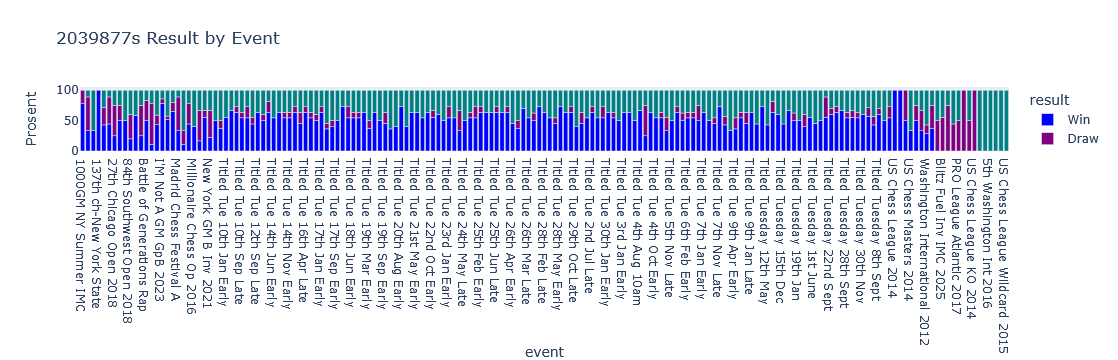

In [95]:
fig = px.bar(
    result,
    x = 'event',
    y = 'Prosent',
    color = 'result',
    barmode = 'relative',
    color_discrete_sequence = ['blue', 'purple', 'teal'], #px.colors.qualitative.T10,
    title = f'{id}s Result by Event',
)
fig.show()

In [96]:
eco_type = games['eco_type'].value_counts().to_frame()
eco_type.reset_index(inplace = True)

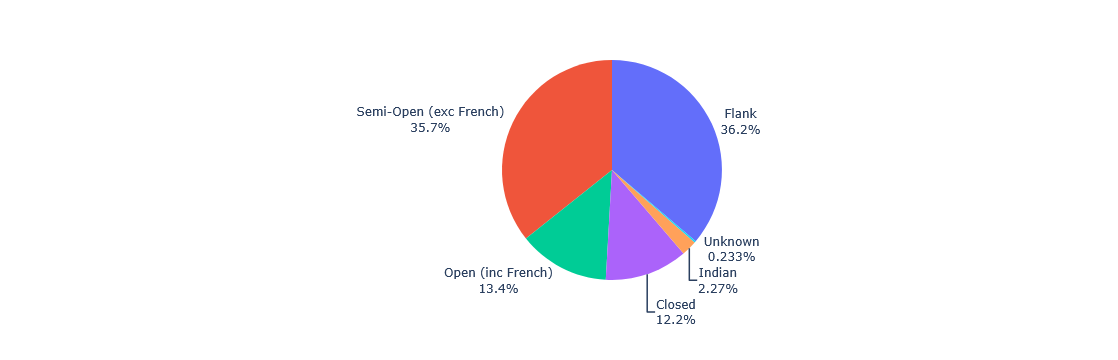

In [97]:
fig = px.pie(
    eco_type, 
    names = 'eco_type',
    values = 'count'
)
fig.update_layout(
    showlegend = False
)
fig.update_traces(
    textposition = 'outside',
    textinfo = 'percent+label'
)
fig.show()

In [98]:
colour = games.groupby('colour')['eco_type'].value_counts(normalize = True).to_frame()
colour

proportion
colour eco_type                          
Black  Semi-Open (exc French)    0.380298
       Flank                     0.360825
       Closed                    0.124857
       Open (inc French)         0.109966
       Indian                    0.022910
       Unknown                   0.001145
White  Flank                     0.363744
       Semi-Open (exc French)    0.332938
       Open (inc French)         0.158768
       Closed                    0.118483
       Indian                    0.022512
       Unknown                   0.003555

In [99]:
col_map = {
    'proportion' : 'Prosent'
}
colour.rename(columns = col_map, inplace = True)
colour['Prosent'] = colour['Prosent'] * 100
colour.reset_index(inplace = True)
colour

,colour,eco_type,Prosent
0,Black,Semi-Open (exc French),38.029782
1,Black,Flank,36.082474
2,Black,Closed,12.485682
3,Black,Open (inc French),10.996564
4,Black,Indian,2.290951
5,Black,Unknown,0.114548
6,White,Flank,36.374408
7,White,Semi-Open (exc French),33.293839
8,White,Open (inc French),15.876777
9,White,Closed,11.848341


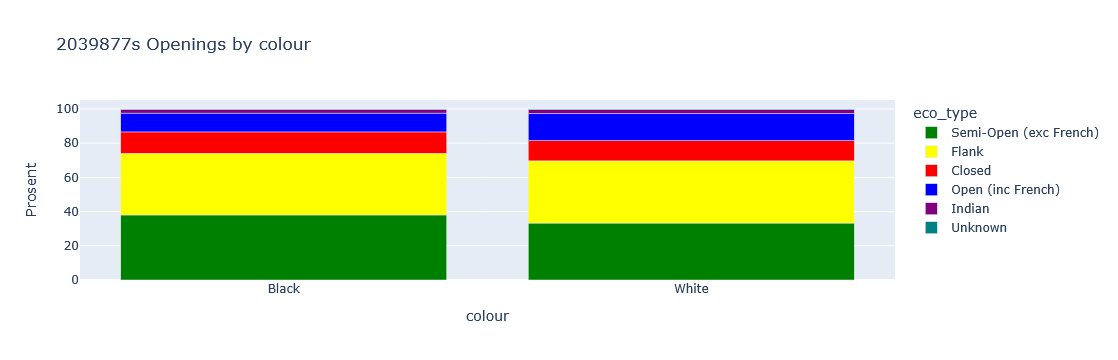

In [100]:
fig = px.bar(
    colour,
    x = 'colour',
    y = 'Prosent',
    color = 'eco_type',
    barmode = 'relative',
    color_discrete_sequence = ['green', 'yellow', 'red', 'blue', 'purple', 'teal'], #px.colors.qualitative.T10,
    title = f'{id}s Openings by colour',
)
fig.show()

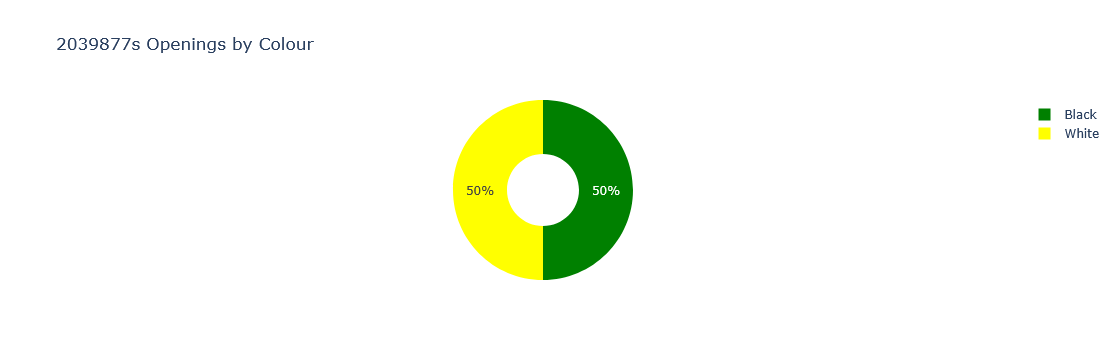

In [101]:
fig = px.pie(
    colour,
    names='colour',
    values='Prosent',
    color='eco_type',
    color_discrete_sequence=['green', 'yellow', 'red', 'blue', 'purple', 'teal'],  # px.colors.qualitative.T10,
    title=f'{id}s Openings by Colour',
    hole=0.4  # This creates the "donut" effect; adjust as needed
)
fig.show()

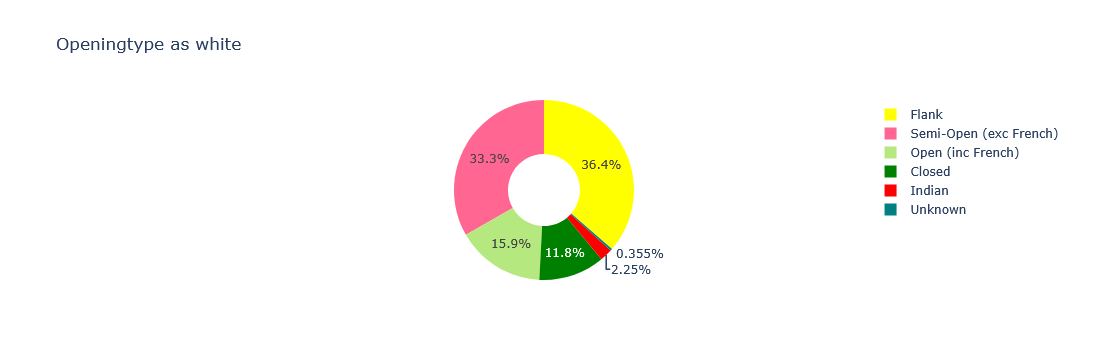

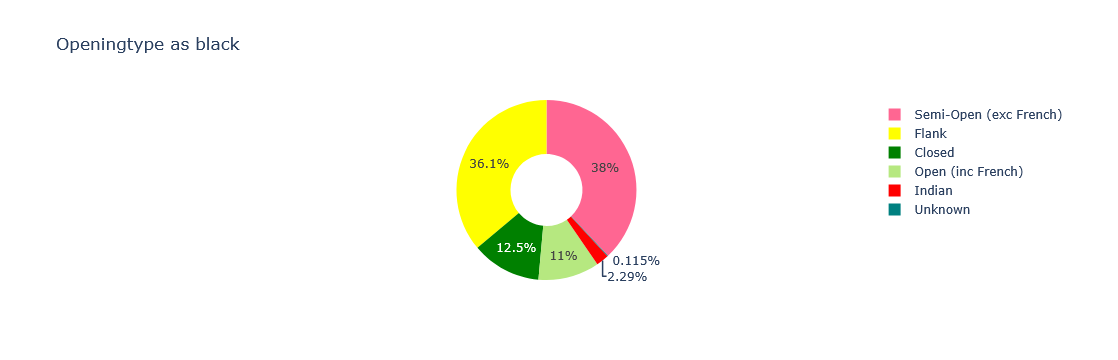

In [103]:
# Filter data for each colour
colour_1 = colour[colour['colour'] == 'White']  # Replace 'Colour 1' with the actual value
colour_2 = colour[colour['colour'] == 'Black']  # Replace 'Colour 2' with the actual value

# Define a consistent color mapping for the 'eco_type' categories
eco_type_color_map = {
    'Closed': 'green',
    'Flank': 'yellow',
    'Indian': 'red',
    'Open (inc french)': 'blue',
    'Semi_open (exc french)': 'purple',
    'Unknown': 'teal'
}

# Create the first donut chart for Colour 1
fig1 = px.pie(
    colour_1,
    names='eco_type',
    values='Prosent',
    color='eco_type',  # Specify the column for color mapping
    color_discrete_map=eco_type_color_map,  # Use the dictionary for consistent colors
    title='Openingtype as white',
    hole=0.4
)

# Create the second donut chart for Colour 2
fig2 = px.pie(
    colour_2,
    names='eco_type',
    values='Prosent',
    color='eco_type',  # Specify the column for color mapping
    color_discrete_map=eco_type_color_map,  # Use the dictionary for consistent colors
    title='Openingtype as black',
    hole=0.4
)

# Display the charts
fig1.show()
fig2.show()

In [24]:
result = games.groupby('eco_type')['result'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
result.rename(columns = col_map, inplace = True)
result['Prosent'] = result['Prosent'] * 100
result.reset_index(inplace = True)
result

,eco_type,result,Prosent
0,Closed,Win,54.491018
1,Closed,Draw,33.532934
2,Closed,Loss,11.976048
3,Flank,Win,67.130435
4,Flank,Draw,21.043478
5,Flank,Loss,11.826087
6,Indian,Win,46.019900
7,Indian,Draw,39.054726
8,Indian,Loss,14.925373
9,Open (inc French),Win,48.816234


In [104]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Filter out the "Unknown" value
filtered_result = result[result['eco_type'] != 'Unknown']

# Define a consistent color mapping for the 'result' categories
result_color_map = {
    'Win': 'green',    # Win for white
    'Loss': 'red',      # Win for black
    'Draw': 'blue'  # Draw
}

# Create a list of unique eco_types (excluding 'Unknown')
eco_types = filtered_result['eco_type'].unique()

# Create a subplot figure with 5 columns (one for each eco_type)
fig = make_subplots(
    rows=1, cols=5,  # 1 row, 5 columns
    subplot_titles=eco_types
)

# Loop through each eco_type and add a pie chart
for i, eco_type in enumerate(eco_types):
    eco_data = filtered_result[filtered_result['eco_type'] == eco_type]  # Filter data for the current eco_type

    # Add a pie chart to the subplot
    fig.add_trace(
        go.Pie(
            labels=eco_data['result'],  # Results (e.g., '1-0', '0-1', '1/2-1/2')
            values=eco_data['Prosent'],  # Percentages
            marker=dict(colors=[result_color_map[result] for result in eco_data['result']]),  # Apply color mapping
            hole=0.4,  # Donut chart
            name=eco_type  # Set the name for hover info
        ),
        row=1, col=i+1  # Place the chart in the appropriate column
    )

# Update the layout
fig.update_layout(
    title_text="Eco Type Results (Excluding Unknown)",  # Title for the entire grid
    showlegend=False,  # Hide legends for individual charts
    height=400,  # Adjust the height of the chart
    width=1200   # Adjust the width to fit 5 charts
)

# Show the figure
fig.show()

KeyError: 'eco_type'

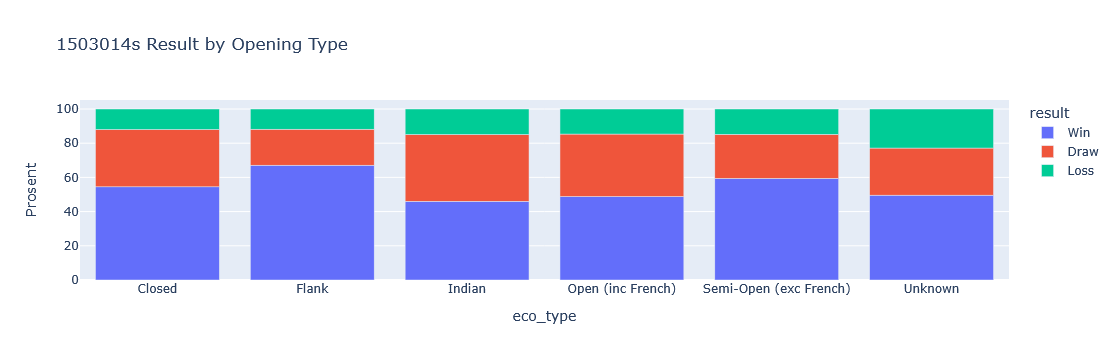

In [25]:
fig = px.bar(
    result,
    x = 'eco_type',
    y = 'Prosent',
    color = 'result',
    barmode = 'relative',
    title = f'{id}s Result by Opening Type',
)
fig.show()

In [26]:
eco = games.groupby('eco_type')['eco'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
eco.rename(columns = col_map, inplace = True)
eco['Prosent'] = eco['Prosent'] * 100
eco.reset_index(inplace = True)
eco

,eco_type,eco,Prosent
0,Closed,D37,13.922156
1,Closed,D02,12.275449
2,Closed,D00,7.784431
3,Closed,D35,5.838323
4,Closed,D38,5.538922
...,...,...,...
318,Semi-Open (exc French),B82,0.098232
319,Semi-Open (exc French),B83,0.098232
320,Semi-Open (exc French),B87,0.098232
321,Semi-Open (exc French),B96,0.098232


In [27]:
fig = px.bar(
    eco,
    x = 'eco_type',
    y = 'Prosent',
    color = 'eco',
    barmode = 'relative',
    title = f'{id}s Openings by Opening Type',
)
fig.show()

In [28]:
endgame = games.groupby('endgame')['result'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
endgame.rename(columns = col_map, inplace = True)
endgame['Prosent'] = endgame['Prosent'] * 100
endgame.reset_index(inplace = True)
endgame

,endgame,result,Prosent
0,2 queen + bishop vs pawn,Win,100.000000
1,2 queen + pawn vs queen + pawns,Loss,50.000000
2,2 queen + pawn vs queen + pawns,Win,50.000000
3,2 queen vs 2 queen,Win,100.000000
4,2 queen vs Unknown,Win,100.000000
...,...,...,...
110,white bishop + pawn vs black bishop and pawn,Win,66.666667
111,white bishop + pawn vs black bishop and pawn,Draw,16.666667
112,white bishop + pawn vs black bishop and pawn,Loss,16.666667
113,white bishop + pawn vs knight + pawns,Loss,100.000000


In [29]:
fig = px.bar(
    endgame,
    x = 'endgame',
    y = 'Prosent',
    color = 'result',
    barmode = 'relative',
    title = f'{id}s Endgame by Result',
)
fig.show()

In [30]:
def find_game_length(row):
    if 'Blitz' in row['event']:  # Check if 'A' is in the 'eco' column
        return 'Blitz'
    if 'Speed' in row['event']:  # Check if 'A' is in the 'eco' column
        return 'Blitz'
    elif 'Rapid' in row['event']:
        return 'Rapid'
    elif 'Titled Tue' in row['event']:
        return 'Chess.com'
    elif 'Chess.com' in row['event']:
        return 'Chess.com'
    elif 'Chess960' in row['event']:
        return 'Chess960'
    elif 'Fischer' in row['event']:
        return 'Chess960'
    else:
        return 'Classic'

In [31]:
games['game length'] = games.apply(find_game_length, axis=1)

C:\Users\Ole Martin\AppData\Local\Temp\ipykernel_16496\2856427536.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [32]:
games

,event,date_played,colour,result,eco,ply_count,termination,endgame,eco_type,game length
0,UNAM Carlsen-Mundo 2012,2012.11.24,White,Win,B90,38.0,resignation,Ended Before Endgame,Semi-Open (exc French),Classic
1,Cuadrangular UNAM 2012,2012.11.24,White,Win,B40,40.0,resignation,Ended Before Endgame,Semi-Open (exc French),Classic
2,Cuadrangular UNAM 2012,2012.11.24,Black,Draw,E43,50.0,draw by agreement,Ended Before Endgame,Indian,Classic
3,Cuadrangular UNAM 2012,2012.11.25,White,Loss,E90,50.0,resignation,Ended Before Endgame,Indian,Classic
4,Cuadrangular UNAM 2012,2012.11.26,Black,Win,B09,44.0,resignation,Ended Before Endgame,Semi-Open (exc French),Classic
...,...,...,...,...,...,...,...,...,...,...
4247,Titled Tue 29th Apr Early,2025.04.29,Black,Draw,A20,70.0,draw by agreement,Ended Before Endgame,Flank,Chess.com
4248,Titled Tue 29th Apr Early,2025.04.29,White,Loss,D31,38.0,resignation,Rook + Pawn vs Rook + Pawn,Closed,Chess.com
4249,Titled Tue 29th Apr Early,2025.04.29,Black,Win,C02,33.0,resignation,Ended Before Endgame,Open (inc French),Chess.com
4250,Titled Tue 29th Apr Early,2025.04.29,White,Loss,A13,28.0,resignation,Ended Before Endgame,Flank,Chess.com


In [33]:
filter1 = games['game length'] == 'Classic'
filter2 = games['game length'] == 'Rapid'
filter3 = games['game length'] == 'Blitz'
filter4 = games['date_played']

In [34]:
filter1

0        True
1        True
2        True
3        True
4        True
        ...  
4247    False
4248    False
4249    False
4250    False
4251    False
Name: game length, Length: 4252, dtype: bool

In [35]:
result = games[filter1].groupby('event')['result'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
result.rename(columns = col_map, inplace = True)
result['Prosent'] = result['Prosent'] * 100
result.reset_index(inplace = True)
# Assuming 'event' and 'date' are in the original 'games' DataFrame
# Extract the first date for each event, if not already present
events_with_dates = games.groupby('event')['date_played'].min().reset_index()
events_with_dates.rename(columns={'date_played': 'event_date'}, inplace=True)

# Merge the event dates into the result DataFrame
result = result.merge(events_with_dates, on='event', how='left')

# Sort the result DataFrame by event_date
result.sort_values(by='event_date', inplace=True)

# Ensure 'event' is a categorical variable with the correct order
result['event'] = pd.Categorical(result['event'], categories=result['event'].unique(), ordered=True)

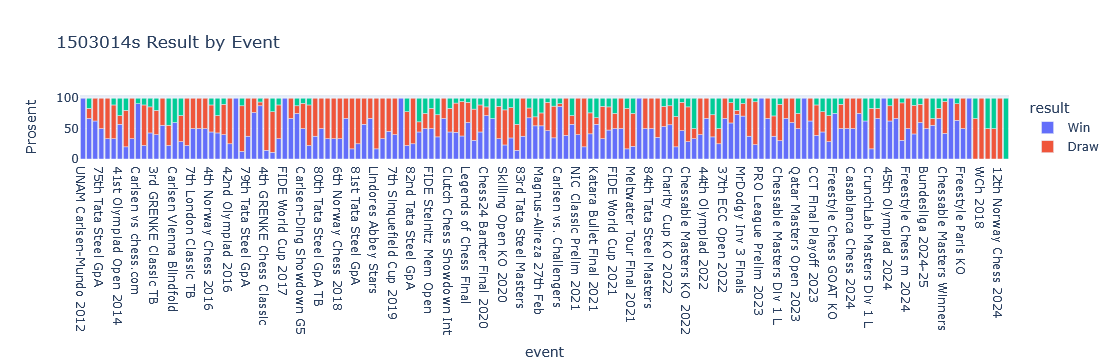

In [36]:
fig = px.bar(
    result,
    x = 'event',
    y = 'Prosent',
    color = 'result',
    barmode = 'relative',
    title = f'{id}s Result by Event',
)
fig.show()

In [37]:
result = games[filter2].groupby('event')['result'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
result.rename(columns = col_map, inplace = True)
result['Prosent'] = result['Prosent'] * 100
result.reset_index(inplace = True)
# Assuming 'event' and 'date' are in the original 'games' DataFrame
# Extract the first date for each event, if not already present
events_with_dates = games.groupby('event')['date_played'].min().reset_index()
events_with_dates.rename(columns={'date_played': 'event_date'}, inplace=True)

# Merge the event dates into the result DataFrame
result = result.merge(events_with_dates, on='event', how='left')

# Sort the result DataFrame by event_date
result.sort_values(by='event_date', inplace=True)

# Ensure 'event' is a categorical variable with the correct order
result['event'] = pd.Categorical(result['event'], categories=result['event'].unique(), ordered=True)

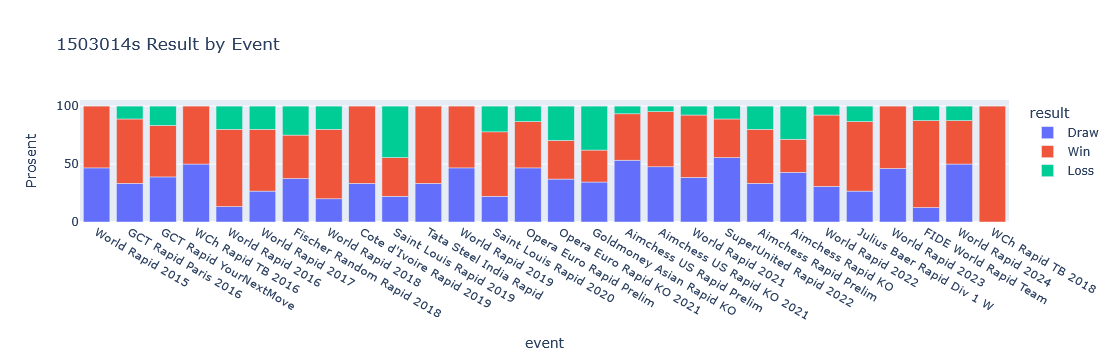

In [38]:
fig = px.bar(
    result,
    x = 'event',
    y = 'Prosent',
    color = 'result',
    barmode = 'relative',
    title = f'{id}s Result by Event',
)
fig.show()

In [39]:
result = games[filter3].groupby('event')['result'].value_counts(normalize = True).to_frame()
col_map = {
    'proportion' : 'Prosent'
}
result.rename(columns = col_map, inplace = True)
result['Prosent'] = result['Prosent'] * 100
result.reset_index(inplace = True)
# Assuming 'event' and 'date' are in the original 'games' DataFrame
# Extract the first date for each event, if not already present
events_with_dates = games.groupby('event')['date_played'].min().reset_index()
events_with_dates.rename(columns={'date_played': 'event_date'}, inplace=True)

# Merge the event dates into the result DataFrame
result = result.merge(events_with_dates, on='event', how='left')

# Sort the result DataFrame by event_date
result.sort_values(by='event_date', inplace=True)

# Ensure 'event' is a categorical variable with the correct order
result['event'] = pd.Categorical(result['event'], categories=result['event'].unique(), ordered=True)

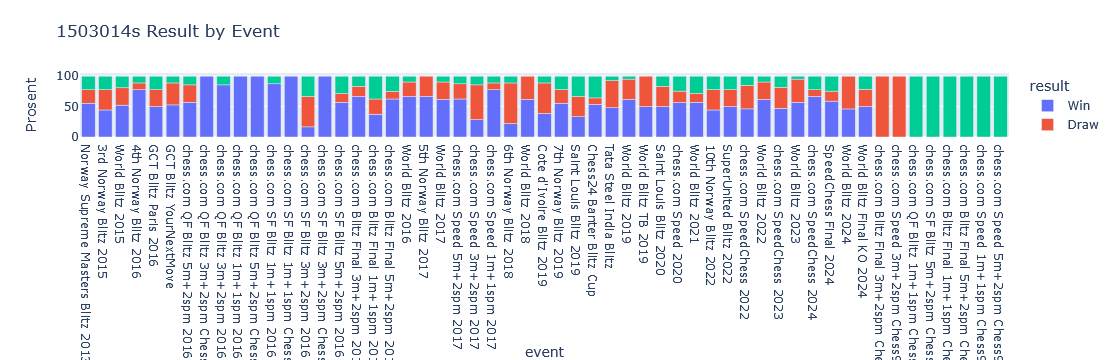

In [40]:
fig = px.bar(
    result,
    x = 'event',
    y = 'Prosent',
    color = 'result',
    barmode = 'relative',
    title = f'{id}s Result by Event',
)
fig.show()

In [41]:
elo = sok2.groupby('event').agg(
    date=('date_played', 'min'),
    elo=('elo', 'first')
).reset_index()

In [42]:
elo['game length'] = elo.apply(find_game_length, axis=1)

In [43]:
import numpy as np

In [44]:
elo = elo.sort_values(by=['date'])

In [46]:
elo

,event,date,elo,game length
276,UNAM Carlsen-Mundo 2012,2012.11.24,2848.0,Classic
97,Cuadrangular UNAM 2012,2012.11.24,2848.0,Classic
22,4th London Chess Classic,2012.12.01,2848.0,Classic
31,75th Tata Steel GpA,2013.01.12,2861.0,Classic
100,FIDE Candidates,2013.03.15,2872.0,Classic
...,...,...,...,...
195,Titled Tue 15th Apr Early,2025.04.15,2837.0,Chess.com
338,grenke Freestyle Open,2025.04.17,2837.0,Classic
219,Titled Tue 22nd Apr Late,2025.04.22,2837.0,Chess.com
218,Titled Tue 22nd Apr Early,2025.04.22,2837.0,Chess.com


In [47]:
elo.index = pd.to_datetime(elo['date'], format='%Y-%m-%d').dt.year

ValueError: time data "2012.11.24" doesn't match format "%Y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

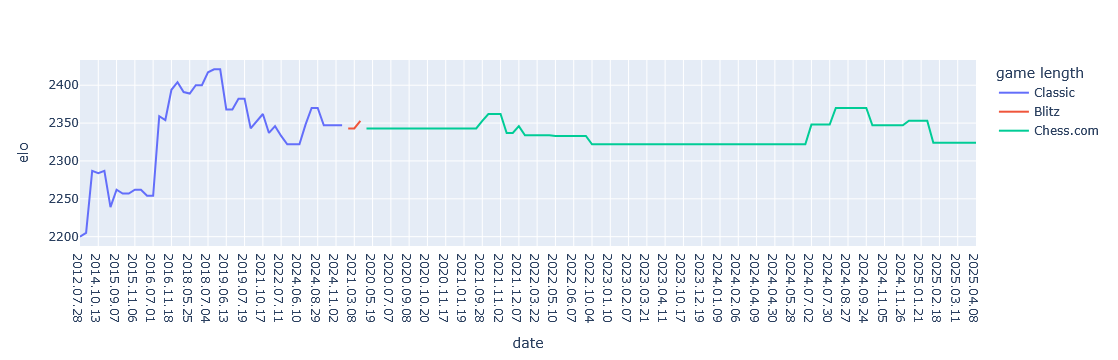

In [59]:
fig = px.line(elo, 
    x= 'date', 
    y= 'elo',
    color = 'game length' # Hva er det fargene skiller på
)
fig.show()